In [ ]:
from collections import defaultdict, Counter
from tqdm.auto import tqdm

from aspa_verification import ASPAVerifier

import pandas as pd
import matplotlib.pyplot as plt
import fastplot

%matplotlib inline

# Find route leaks

Running this section of the notebook requires `data/caida/2026-03-paths-detailed.txt`: a 40 GB file from containing all paths observed across the midnight dumps of all RIPE NCC and RouteViews RRCs between March 1st and 5th.
From this file, AS Paths are extracted and processed as follows:
1. Compress each path
2. Extract all subpaths
3. Keep only paths with 3 or more ASes

Paths are then validated according to the algorithm presented in the paper, and invalid paths are saved to `data/2026-03-invalid-paths.txt` for further analyses.

In [3]:
df = pd.read_csv('data/vaps.csv')
df['date'] = pd.to_datetime(df['date'])

df = df[(df['date'] >= '2026-03-01') & (df['date'] < '2026-03-06')]
df = df.drop_duplicates('customer', keep='last')

df['asn_customer'] = df['customer'].apply(lambda s: s[2:])

aspa = df.set_index('asn_customer')['providers'].apply(lambda prov: set(prov.replace('AS', '').split(' '))).to_dict()

In [ ]:
# 15 seconds
raw_paths = list()

with open('data/caida/2026-03-paths.txt', 'r') as f:
    raw_paths = [line.strip() for line in f]

print(f'Loaded {len(raw_paths)} paths')

Loaded 49907751 paths


In [ ]:
# ~5 minutes of preprocessing:
# (1) compress each path
# (2) extract all subpaths
# (3) keep only paths with 3 or more ASes

def compress(path: list) -> list:
    # assumes path is a list of len > 0
    result = [path[0],]
    for asn in path:
        if asn != result[-1]:
            result.append(asn)

    return result


all_paths = set()

for path_str in raw_paths:
    path = path_str.split('|')
    path = compress(path)
    
    for i in range(len(path) - 2):
        subpath = path[i:]
        subpath_str = '|'.join(subpath)
        all_paths.add(subpath_str)

with open('AS_paths.txt', 'w') as f:
    for path_str in all_paths:
        f.write(f'{path_str}\n')

print(f'Pre-processed and filtered paths: {len(all_paths)}')

Pre-processed and filtered paths: 56708620


In [3]:
all_paths = set()

with open('AS_paths.txt', 'r') as f:
    for line in f:
        path_str = line.strip()
        all_paths.add(path_str)

In [ ]:
from pathlib import Path
import subprocess
import sys

PATHS = Path("AS_paths.txt")
PATHS_DETAILS = Path("data/caida/2026-03-paths-detailed.txt")

def load_as_paths():
    all_paths = set()
    with PATHS.open("r") as f:
        for line in f:
            path_str = line.strip()
            all_paths.add(path_str)

    return all_paths

def compress(path):
    result = [path[0]]
    for asn in path[1:]:
        if asn != result[-1]:
            result.append(asn)

    return result

def build_as_paths():
    all_paths = set()

    with PATHS_DETAILS.open("r") as f:
        for line in f:
            parts = line.strip().split(" ")
            if len(parts) <= 1:
                continue

            raw_path = parts[1]
            path = compress(raw_path.split("|"))
            
            for i in range(len(path) - 2):
                subpath = '|'.join(path[i:])
                all_paths.add(subpath)

    with PATHS.open("w") as f:
        for p in all_paths:
            f.write(p + "\n")
            
    return all_paths

if PATHS.exists():
    print("AS_paths.txt found, loading paths...")
    all_paths = load_as_paths()
elif PATHS_DETAILS.exists():
    print("Processing 2026-03-paths-detailed.txt, saving to AS_paths.txt...")
    all_paths = build_as_paths()
else:
    print("Downloading CAIDA data...")
    subprocess.run([sys.executable, "get_caida_data.py", "--paths"], check=True)
    all_paths = build_as_paths()

print(f"Loaded {len(all_paths)} paths")

AS_paths.txt found, loading paths...
Loaded 56708620 paths


In [ ]:
# ~15 minutes

verifier = ASPAVerifier(aspa)

data = defaultdict(set)

outcome_by_tactic = {
    'upstream': Counter(),
    'fallback': Counter()
}

# paths are already compressed and filtered from the pre-proccesing
for path_str in tqdm(all_paths):

    path = path_str.split('|')

    receiver = path[0]
    neighbor = path[1]
    received_path = path[1:]

    outcome = 'N/A'
    
    if receiver in aspa and neighbor not in aspa[receiver]:
        outcome = verifier.verify_upstream_path(received_path)
        outcome_by_tactic['upstream'][outcome] += 1
    else:
        o1 = verifier.verify_upstream_path(received_path)
        o2 = verifier.verify_downstream_path(received_path)

        if o1 == "Invalid" and o2 == "Invalid":
            outcome = "Invalid"
        elif o1 == "Unknown" and o2 == "Unknown":
            outcome = "Unknown"
        elif o1 == "Valid" and o2 == "Valid":
            outcome = "Valid"

        outcome_by_tactic['fallback'][outcome] += 1

    data[outcome].add(path_str)

In [71]:
outcome_by_tactic

{'upstream': Counter({'Unknown': 2826034, 'Valid': 26211, 'Invalid': 13956}),
 'fallback': Counter({'Unknown': 39799746,
          'N/A': 13814343,
          'Valid': 205631,
          'Invalid': 22699})}

In [11]:
tot = sum(len(v) for v in data.values())
for k, v in data.items():
    print(k, f'{len(v)} ({len(v) / tot * 100:.2f}%)')

Unknown 42625780 (75.17%)
N/A 13814343 (24.36%)
Valid 231842 (0.41%)
Invalid 36655 (0.06%)


In [ ]:
invalid_paths = data['Invalid']

with open('data/2026-03-invalid-paths.txt', 'w') as f:
    for path in data['Invalid']:
        f.write(f'{path}\n')

# Invalid paths analyses
Analysis of the 36655 invalid paths identified in the previous section.

In [2]:
df = pd.read_csv('data/vaps.csv')
df['date'] = pd.to_datetime(df['date'])

df = df[(df['date'] >= '2026-03-01') & (df['date'] < '2026-03-06')]
df = df.drop_duplicates('customer', keep='last')

df['asn_customer'] = df['customer'].apply(lambda s: s[2:])

aspa = df.set_index('asn_customer')['providers'].apply(lambda prov: set(prov.replace('AS', '').split(' '))).to_dict()
verifier = ASPAVerifier(aspa)

invalid_paths = set()
with open('data/2026-03-invalid-paths.txt', 'r') as f:
    for line in f:
        invalid_paths.add(line.strip())

## Minimal invalid paths

In [3]:
# Find minimal invalid paths (MIPs), i.e., the set of smallest (unique) invalid subpath across all 36k invalid paths
# The MIP includes the receiving AS
mip = set()
mip_data = defaultdict(set)

for path_str in invalid_paths:
    path = path_str.split('|')

    offset = 1

    while offset < len(path) - 2:
        subpath = path[offset:]
        
        receiver = subpath[0]
        neighbor = subpath[1]
        received_path = subpath[1:]
        
        outcome = 'N/A'
        
        if receiver in aspa and neighbor not in aspa[receiver]:
            outcome = verifier.verify_upstream_path(received_path)
        else:
            o1 = verifier.verify_upstream_path(received_path)
            o2 = verifier.verify_downstream_path(received_path)
            
            if o1 == "Invalid" and o2 == "Invalid":
                outcome = "Invalid"
        
        if outcome != "Invalid":
            root = path[offset - 1:]
            root_str = '|'.join(path[(offset - 1):])
            mip.add(root_str)
            mip_data[root_str].add(path_str)
            break
        
        offset += 1

print(f'MIPs: {len(mip)}')

MIPs: 11924


In [4]:
root_len = Counter()

for path_str in mip:
    path = path_str.split('|')
    n = len(path)
    root_len[n] += 1

print(root_len.most_common())

[(4, 5822), (5, 4392), (6, 1222), (7, 351), (8, 105), (9, 29), (19, 1), (10, 1), (11, 1)]


In [5]:
# to how many ASes each MIP is directly propagated?
mip_propagated_to_direct = defaultdict(set)
mip_propagated_to_all = defaultdict(set)

for mip_str, full_invalid_paths in mip_data.items():
    # mip_data is a dict: key is the MIP, value is the set of all invalid paths that share that MIP
    mip_path = mip_str.split('|')
    for path_str in full_invalid_paths:
        path = path_str.split('|')
        suffix_path = path[:-len(mip_path)]
        if len(suffix_path) > 0:
            mip_propagated_to_direct[mip_str].add(suffix_path[-1])
            for asn in suffix_path:
                mip_propagated_to_all[mip_str].add(asn)
        else:
            # the MIP is not propagated at all
            continue


direct_propagation_counter = Counter()
# add as many zeros as the number of MIPs that are not propagated at all
plot_data_direct = [0] * (len(mip) - len(mip_propagated_to_direct))
for _mip, propagated_to in mip_propagated_to_direct.items():
    direct_propagation_counter[len(propagated_to)] += 1
    plot_data_direct.append(len(propagated_to))

indirect_propagation_counter = Counter()
# add as many zeros as the number of MIPs that are not propagated at all
plot_data_all = [0] * (len(mip) - len(mip_propagated_to_all))
for _mip, propagated_to in mip_propagated_to_all.items():
    indirect_propagation_counter[len(propagated_to)] += 1
    plot_data_all.append(len(propagated_to))

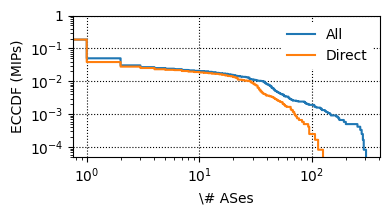

In [6]:
fig, ax = plt.subplots(figsize=(4, 2.25))

ax.ecdf(plot_data_all, complementary=True, label='All')
ax.ecdf(plot_data_direct, complementary=True, label='Direct')

ax.set_xscale('log')
ax.set_yscale('log')
legend = ax.legend(fancybox=False, frameon=True, loc='upper right')
legend.get_frame().set_linewidth(0.0)
legend.get_frame().set_alpha(1)

ax.grid(True, which="major", ls="dotted", color='k')
ax.set_ylim(5 * 10e-6, 1)
ax.set_xlabel(r'\# ASes')
ax.set_ylabel('ECCDF (MIPs)')

ax.set_yticks([1, 0.1, 0.01, 0.001, 0.0001])
ax.set_yticklabels(['1', '$10^{-1}$', '$10^{-2}$', '$10^{-3}$', '$10^{-4}$'])

plt.tight_layout()

plt.savefig('figures/mip_propagation.pdf', bbox_inches='tight')

In [7]:
mip_sources = Counter()
mip_presence = Counter()

for path_str in mip:
    path = path_str.split('|')
    mip_sources[path[-1]] += 1
    for asn in path[1:]:
        mip_presence[asn] += 1

print(f"MIPs are originated by {len(mip_sources)} ASes")
print(mip_sources.most_common(5))

print(f"ASes found in MIPs: {len(mip_presence)}")
print(mip_presence.most_common(5))

MIPs are originated by 3677 ASes
[('61574', 197), ('271150', 99), ('61625', 74), ('2716', 62), ('48595', 56)]
ASes found in MIPs: 4312
[('6939', 6061), ('1299', 2682), ('57463', 1800), ('12735', 1756), ('52091', 1112)]


# Invalid paths over time

The data required to run this notebook is already provided.
To obtain it, we run the following scripts:

1. Identify all vantage points that observed invalid paths:
```bash
python get_rrc_vps.py --workers 50
```

2. Download RRC data across March from the identified vantage points. (**NOTE: this will take hours *if not days* to run**). The script relies on [bgpkit-parser](https://github.com/bgpkit/bgpkit-parser) to fetch and parse RRC data.
```bash
for day in {00..31}; do
    python fetch_rrc_data.py 2026 03 {day};
done
```

## Results

In [9]:
invalid_paths = set()

with open('data/2026-03-invalid-paths.txt', 'r') as f:
    for line in f:
        invalid_paths.add(line.strip())

# associate each date with the set of invalid paths that were observed on that date in the RRC data
invalid_paths_matched = defaultdict(set)

for date in pd.date_range(start='2026-03-01', end='2026-03-30', freq='D'):
    date_str = date.strftime('%Y-%m-%d')
    with open(f'rrc/out/{date_str}.txt', 'r') as f:
        for line in f:
            path_str = line.strip()
            invalid_paths_matched[date_str].add(path_str)

invalid_paths_periods = (
    pd
        .DataFrame(invalid_paths_matched.items(), columns=['date', 'matched'])
        .astype({'date': 'datetime64[ns]'})
        .groupby(pd.Grouper(key='date', freq='5D'))
        .agg(lambda sets: set().union(*sets))
        ['matched']
        .pipe(lambda s: s.set_axis(s.index + pd.Timedelta(days=4)))
        .rename(index=lambda ts: ts.strftime('%Y-%m-%d'))
        .to_dict()
)

In [10]:
df = pd.read_csv('data/vaps.csv')
df['date'] = pd.to_datetime(df['date'])

df = df[df['date'] >= '2026-03-01']
df['customer'] = df['customer'].apply(lambda s: s[2:])
df['providers'] = df['providers'].apply(lambda provs: set(p[2:] for p in provs.split(' ')))

# We only monitor changes to ASPA objects belonging to the Customer ASes that were involved in the initial invalid paths analysis
CUSTOMERS = set(df[df['date'] < '2026-03-06']['customer'])
df = df[df['customer'].isin(CUSTOMERS)]

announced_invalid = Counter()
announced_valid = Counter()
not_announced_invalid = Counter()
not_announced_valid = Counter()


for date_str in ('2026-03-05', '2026-03-10', '2026-03-15', '2026-03-20', '2026-03-25', '2026-03-30'):
    
    df_part = df[df['date'] <= date_str]
    df_part = df_part.sort_values('date')
    df_part.drop_duplicates('customer', keep='last')
    
    period_aspa = df_part.set_index('customer')['providers'].to_dict()
    period_verifier = ASPAVerifier(period_aspa)

    for path_str in invalid_paths:
        path = path_str.split('|')
        receiver = path[0]
        neighbor = path[1]
        received_path = path[1:]

        outcome = 'N/A'
    
        if receiver in period_aspa and neighbor not in period_aspa[receiver]:
            outcome = period_verifier.verify_upstream_path(received_path)
        else:
            o1 = period_verifier.verify_upstream_path(received_path)
            o2 = period_verifier.verify_downstream_path(received_path)

            if o1 == "Invalid" and o2 == "Invalid":
                outcome = "Invalid"
            if o1 == "Valid" and o2 == "Valid":
                outcome = "Valid"
            if o1 == "Unknown" and o2 == "Unknown":
                outcome = "Unknown"

        if path_str in invalid_paths_periods[date_str]:
            if outcome == "Invalid":
                announced_invalid[date_str] += 1
            else:
                announced_valid[date_str] += 1
        else:
            if outcome == "Invalid":
                not_announced_invalid[date_str] += 1
            else:
                not_announced_valid[date_str] += 1

In [11]:
plot_data_dict = dict()
tot_invalid_paths = len(invalid_paths)

# each day, how many were announced/not and how many were valid/invalid
for date_str in ('2026-03-05', '2026-03-10', '2026-03-15', '2026-03-20', '2026-03-25', '2026-03-30'):
    # print(f'{date_str}:')
    # print(f'\tAnnounced Invalid: {announced_invalid[date_str] / len(invalid_paths) * 100:.2f}%')
    # print(f'\tAnnounced Valid: {announced_valid[date_str] / len(invalid_paths) * 100:.2f}%')
    # print(f'\tNot Announced Invalid: {not_announced_invalid[date_str] / len(invalid_paths) * 100:.2f}%')
    # print(f'\tNot Announced Valid: {not_announced_valid[date_str] / len(invalid_paths) * 100:.2f}%')
    plot_data_dict[pd.to_datetime(date_str)] = {
        'Announced, Invalid': announced_invalid[date_str] / tot_invalid_paths * 100,
        'Announced, Other': announced_valid[date_str] / tot_invalid_paths * 100,
        'Not announced': (not_announced_invalid[date_str] + not_announced_valid[date_str]) / tot_invalid_paths * 100,
    }

plot_data = pd.DataFrame(plot_data_dict).T

<Figure size 640x480 with 0 Axes>

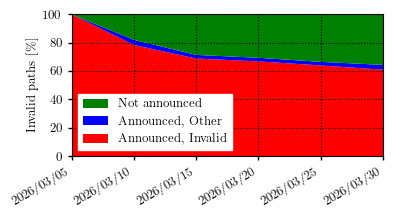

In [12]:
fastplot.plot(plot_data, None, mode='timeseries_stacked',
              style='latex', legend=False, grid=True, fontsize=9,
            #   cycler=CUSTOM_CYCLER,
              ylabel=r'Invalid paths [\%]', ytick_direction='out', # ylim=(0, 1400),
              xticks=[(pd.date_range(start='2026-03-05', end='2026-03-30', freq='5D')), None],
              xtick_direction='out', xticks_rotate=30)

handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.gca().legend(
    handles[::-1], labels[::-1], loc='best', ncol=1, fontsize=9, numpoints=1,
    frameon=True, facecolor='white', edgecolor='white', framealpha=1, fancybox=False)

plt.savefig('figures/invalid_paths_over_time.pdf', bbox_inches='tight')

## Do paths no longer Invalid subsequently revert to Invalid?

In [13]:
df = pd.read_csv('data/vaps.csv')
df['date'] = pd.to_datetime(df['date'])

df = df[df['date'] >= '2026-03-01']
df['customer'] = df['customer'].apply(lambda s: s[2:])
df['providers'] = df['providers'].apply(lambda provs: set(p[2:] for p in provs.split(' ')))

# To monitor only changes to ASPAs of those that were involved in the initial invalid paths
CUSTOMERS = set(df[df['date'] < '2026-03-06']['customer'])
df = df[df['customer'].isin(CUSTOMERS)]

outcomes_per_day = dict()
ASES_THAT_UPDATED_ASPA = set()
prev_period_aspa = dict()

# % of invalid paths that are still invalid
plot_data_invalidity = dict()
for date_str in ('2026-03-05', '2026-03-10', '2026-03-15', '2026-03-20', '2026-03-25', '2026-03-30'):
    outcomes_per_day[date_str] = defaultdict(set)
    
    df_part = df[df['date'] <= date_str]
    df_part = df_part.sort_values('date')
    df_part.drop_duplicates('customer', keep='last')
    
    period_aspa = df_part.set_index('customer')['providers'].to_dict()
    period_verifier = ASPAVerifier(period_aspa)

    # ASes whose ASPA changed since the previous period
    if date_str != '2026-03-05':
        changed_asns = {
            asn for asn in set(period_aspa) | set(prev_period_aspa)
            if period_aspa.get(asn) != prev_period_aspa.get(asn)
        }
        ASES_THAT_UPDATED_ASPA |= changed_asns
        
    prev_period_aspa = period_aspa
    
    for path_str in invalid_paths:
        path = path_str.split('|')
        receiver = path[0]
        neighbor = path[1]
        received_path = path[1:]

        outcome = 'Other'
    
        if receiver in period_aspa and neighbor not in period_aspa[receiver]:
            outcome = period_verifier.verify_upstream_path(received_path)
        else:
            o1 = period_verifier.verify_upstream_path(received_path)
            o2 = period_verifier.verify_downstream_path(received_path)

            if o1 == "Invalid" and o2 == "Invalid":
                outcome = "Invalid"
            if o1 == "Valid" and o2 == "Valid":
                outcome = "Other"
            if o1 == "Unknown" and o2 == "Unknown":
                outcome = "Other"

        outcomes_per_day[date_str][outcome].add(path_str)

In [14]:
# paths that went from Valid back to Invalid
invalid_to_valid_to_invalid = set()
for day1, day2 in zip(
        ['2026-03-05', '2026-03-10', '2026-03-15', '2026-03-20', '2026-03-25'],
        ['2026-03-10', '2026-03-15', '2026-03-20', '2026-03-25', '2026-03-30']
    ):
    invalid_to_valid_to_invalid |= (outcomes_per_day[day1]['Other'] & outcomes_per_day[day2]['Invalid'])

print(invalid_to_valid_to_invalid)

set()
